<a href="https://colab.research.google.com/github/Lauriano-Viana/fase-06-desafio-sp-02/blob/main/fase06_challenge_sprint_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# montar o google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 1. Preparação dos Dados

## Seguintes etapas:
    1)  Lê o arquivo .tiff
    2)  Recorta patches de 256x256 pixels
    3)  Calcula o NDVI médio de cada patch
    4)  Classifica em Alta/Baixa produtividade automaticamente
    5)  Salva os patches em .png
    6)  Cria o CSV de metadados

Instalação das bibliotecas necessarias

In [ ]:
!pip install rasterio
!pip install numpy
!pip install pandas
!pip install pillow
!pip install matplotlib
!pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 100.2 MB/s eta 0:00:00


In [ ]:
# imports
import os
import numpy as np
import pandas as pd
import rasterio
from rasterio.windows import Window
from PIL import Image

# Configurações
input_folder = '/content/drive/MyDrive/fase-06-challenge-sp-02/fontes-dados/tiff'
output_folder ='/content/drive/MyDrive/fase-06-challenge-sp-02/fontes-dados/patches_png'
csv_path = '/content/drive/MyDrive/fase-06-challenge-sp-02/fontes-dados/metadata.csv'
patch_size = 256
years = range(2020, 2025)

os.makedirs(output_folder, exist_ok=True)

metadata = []

def calculate_ndvi_mean(patch_array):
    patch_array = patch_array.astype(np.float32)
    ndvi = (patch_array[3] - patch_array[2]) / (patch_array[3] + patch_array[2] + 1e-6)
    return np.nanmean(ndvi)

for year in years:
    input_tiff = os.path.join(input_folder, f'NDVI_{year}.tif')

    if not os.path.isfile(input_tiff):
        print(f"[⚠️] Arquivo TIFF não encontrado para {year}: {input_tiff}")
        continue

    print(f"🔵 Processando {input_tiff}")

    try:
        with rasterio.open(input_tiff) as src:
            width = src.width
            height = src.height
            bands = src.read()

            print(f"Imagem {year}: {width}x{height} pixels, {bands.shape[0]} bandas.")

            if bands.shape[0] < 4:
                print(f"[⚠️] Imagem do ano {year} não tem bandas suficientes! ({bands.shape[0]} bandas)")
                continue

            patch_id = 0
            for top in range(0, height, patch_size):
                for left in range(0, width, patch_size):
                    window = Window(left, top, patch_size, patch_size)

                    if left + patch_size > width or top + patch_size > height:
                        continue

                    patch = src.read(window=window)

                    if patch.shape[0] < 4:
                        continue

                    ndvi_mean = calculate_ndvi_mean(patch)
                    label = 1 if ndvi_mean > 0.4 else 0

                    rgb_patch = patch[[2,1,0], :, :]
                    rgb_patch = np.transpose(rgb_patch, (1,2,0))
                    rgb_patch = (255 * (rgb_patch - np.min(rgb_patch)) / (np.max(rgb_patch) - np.min(rgb_patch) + 1e-6)).astype(np.uint8)

                    patch_filename = f"patch_{year}_{patch_id}.png"
                    Image.fromarray(rgb_patch).save(os.path.join(output_folder, patch_filename))

                    metadata.append({
                        'filename': patch_filename,
                        'year': year,
                        'mean_ndvi': ndvi_mean,
                        'label': label
                    })

                    patch_id += 1

            print(f"✅ Ano {year} processado. Total de patches: {patch_id}")

    except Exception as e:
        print(f"[❌] Erro ao processar {year}: {e}")

# Salva o CSV final
if metadata:
    df = pd.DataFrame(metadata)
    df.to_csv(csv_path, index=False)
    print(f"\n🏁 CSV final salvo em {csv_path}")
else:
    print("\n⚠️ Nenhum patch gerado. Verifique os arquivos TIFF.")


🔵 Processando /content/drive/MyDrive/fase-06-challenge-sp-02/fontes-dados/tiff/NDVI_2020.tif
Imagem 2020: 1999x2004 pixels, 23 bandas.


<ipython-input-3-6f6c230c3841>:23: RuntimeWarning: Mean of empty slice
  return np.nanmean(ndvi)
<ipython-input-3-6f6c230c3841>:64: RuntimeWarning: invalid value encountered in cast
  rgb_patch = (255 * (rgb_patch - np.min(rgb_patch)) / (np.max(rgb_patch) - np.min(rgb_patch) + 1e-6)).astype(np.uint8)


✅ Ano 2020 processado. Total de patches: 49
🔵 Processando /content/drive/MyDrive/fase-06-challenge-sp-02/fontes-dados/tiff/NDVI_2021.tif
Imagem 2021: 1999x2004 pixels, 23 bandas.
✅ Ano 2021 processado. Total de patches: 49
🔵 Processando /content/drive/MyDrive/fase-06-challenge-sp-02/fontes-dados/tiff/NDVI_2022.tif
Imagem 2022: 1999x2004 pixels, 23 bandas.
✅ Ano 2022 processado. Total de patches: 49
🔵 Processando /content/drive/MyDrive/fase-06-challenge-sp-02/fontes-dados/tiff/NDVI_2023.tif
Imagem 2023: 1999x2004 pixels, 20 bandas.
✅ Ano 2023 processado. Total de patches: 49
🔵 Processando /content/drive/MyDrive/fase-06-challenge-sp-02/fontes-dados/tiff/NDVI_2024.tif
Imagem 2024: 1999x2004 pixels, 20 bandas.
✅ Ano 2024 processado. Total de patches: 49

🏁 CSV final salvo em /content/drive/MyDrive/fase-06-challenge-sp-02/fontes-dados/metadata.csv


# 2. Análise dos dados

## Definição das Variaveis
    mean_ndvi_patch → valor médio do patch (principal variável)
    year → ano de coleta (pode ser tratado como categórico)
    mean_ndvi_satveg → NDVI médio do SATVeg no ano
    std_ndvi_satveg → desvio padrão do NDVI no ano
    anomalia de NDVI → (mean_ndvi_patch - mean_ndvi_satveg)

In [ ]:
# Importações
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
# 1. Ler o CSV dos patches
patches_df = pd.read_csv('/content/drive/MyDrive/fase-06-challenge-sp-02/fontes-dados/metadata.csv')

# 2. Ler o XLS do SATVeg corretamente
satveg_df = pd.read_excel('/content/drive/MyDrive/fase-06-challenge-sp-02/fontes-dados/SATVEG-DADOS/satveg_planilha.xlsx', decimal=',')  # <- importante o decimal=','

# Corrigir tipos
satveg_df['Data'] = pd.to_datetime(satveg_df['Data'], dayfirst=True)  # <- importante dayfirst=True
satveg_df['year'] = satveg_df['Data'].dt.year

# 1. Agregar SATVeg
satveg_yearly = satveg_df.groupby('year').agg({
    'NDVI': ['mean', 'std']
}).reset_index()
satveg_yearly.columns = ['year', 'mean_ndvi_satveg', 'std_ndvi_satveg']

# 2. Juntar patches com SATVeg
patches_enriched = pd.merge(patches_df, satveg_yearly, on='year')


# 3. Calcular anomalia
patches_enriched['ndvi_anomaly'] = patches_enriched['mean_ndvi'] - patches_enriched['mean_ndvi_satveg']
patches_enriched.to_csv('patches_enriched.csv', index=False)

# 4. Resultado
print(patches_enriched.head())

           filename  year  mean_ndvi  label  mean_ndvi_satveg  \
0  patch_2020_0.png  2020        NaN      0           0.56043   
1  patch_2020_1.png  2020  -0.152042      0           0.56043   
2  patch_2020_2.png  2020  -0.123972      0           0.56043   
3  patch_2020_3.png  2020  -0.076947      0           0.56043   
4  patch_2020_4.png  2020  -0.101810      0           0.56043   

   std_ndvi_satveg  ndvi_anomaly  
0         0.100349           NaN  
1         0.100349     -0.712472  
2         0.100349     -0.684403  
3         0.100349     -0.637377  
4         0.100349     -0.662240  


## Normalizando os dados do patches_enriched.csv

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Carregar o dataset
df = pd.read_csv('patches_enriched.csv')

# 1. Substituir NaN (valores ausentes)

# Substituir mean_ndvi e ndvi_anomaly por suas médias (ou você pode usar outro critério)
df['mean_ndvi'] = df['mean_ndvi'].fillna(df['mean_ndvi'].mean())
df['ndvi_anomaly'] = df['ndvi_anomaly'].fillna(df['ndvi_anomaly'].mean())

# (Opcional) Se quiser, substitua por 0:
# df = df.fillna(0)

# 2. Selecionar colunas numéricas para normalização
numeric_cols = ['mean_ndvi', 'mean_ndvi_satveg', 'std_ndvi_satveg', 'ndvi_anomaly']

# MinMaxScaler (0 a 1)
minmax_scaler = MinMaxScaler()
df_minmax = df.copy()
df_minmax[numeric_cols] = minmax_scaler.fit_transform(df_minmax[numeric_cols])

# OU: StandardScaler (distribuição normal: média 0, desvio padrão 1)
standard_scaler = StandardScaler()
df_standard = df.copy()
df_standard[numeric_cols] = standard_scaler.fit_transform(df_standard[numeric_cols])

# Salvar os arquivos prontos (opcional)
df_minmax.to_csv('patches_normalized_minmax.csv', index=False)
df_standard.to_csv('patches_normalized_standard.csv', index=False)

print("Normalização concluída!")


Normalização concluída!


## Analisar a relação entre NDVI e produtividade

Correlação entre NDVI Patch e SATVeg: 0.42


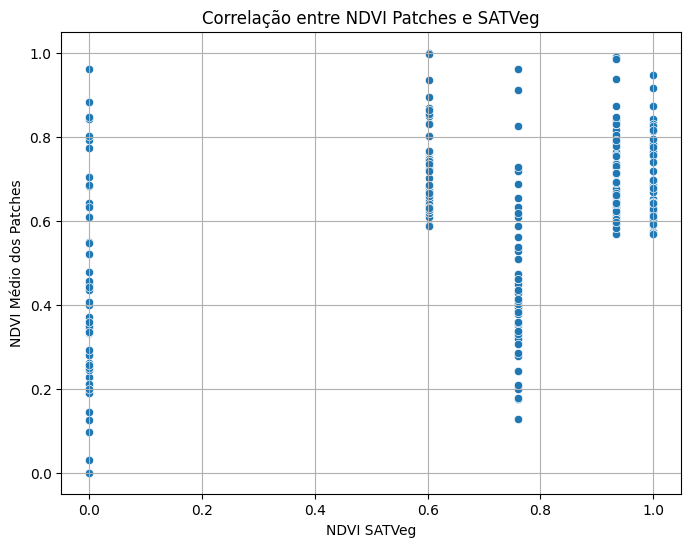

In [ ]:
# Carregar
patches_enriched = pd.read_csv('patches_normalized_minmax.csv')

# Correlação entre NDVI do patch e NDVI médio do SATVeg
correlation = patches_enriched['mean_ndvi'].corr(patches_enriched['mean_ndvi_satveg'])
print(f'Correlação entre NDVI Patch e SATVeg: {correlation:.2f}')

# Visualizar com scatterplot
plt.figure(figsize=(8,6))
sns.scatterplot(x='mean_ndvi_satveg', y='mean_ndvi', data=patches_enriched)
plt.title('Correlação entre NDVI Patches e SATVeg')
plt.xlabel('NDVI SATVeg')
plt.ylabel('NDVI Médio dos Patches')
plt.grid(True)
plt.show()

## Identificar períodos críticos de crescimento

Período crítico = onde NDVI ficou abaixo da média menos 1 desvio padrão.

NDVI crítico (Média - 1 Desvio Padrão): 0.40
Anos críticos identificados: [2020 2021]


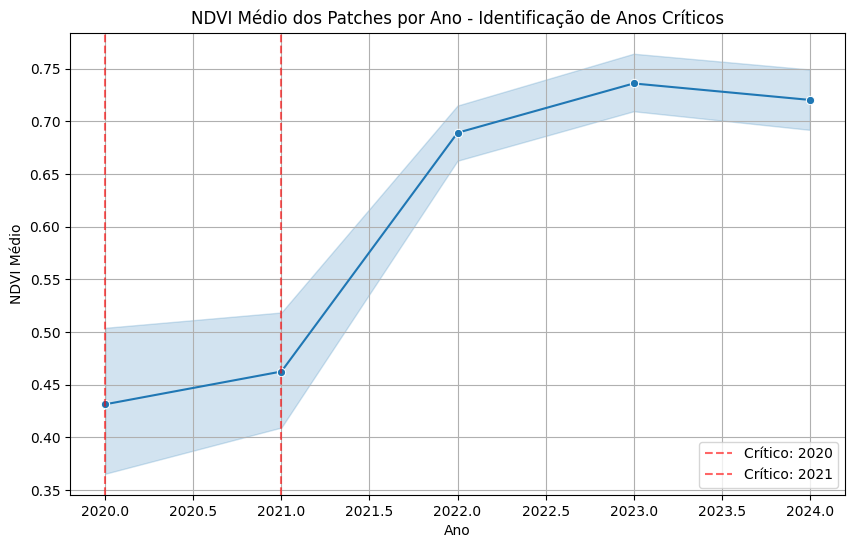

In [ ]:
# Definir NDVI crítico
ndvi_mean = patches_enriched['mean_ndvi'].mean()
ndvi_std = patches_enriched['mean_ndvi'].std()
critical_threshold = ndvi_mean - ndvi_std

print(f'NDVI crítico (Média - 1 Desvio Padrão): {critical_threshold:.2f}')

# Filtrar anos críticos
critical_years = patches_enriched[patches_enriched['mean_ndvi'] < critical_threshold]['year'].unique()
print(f"Anos críticos identificados: {critical_years}")

# Plotar os anos críticos
plt.figure(figsize=(10,6))
sns.lineplot(x='year', y='mean_ndvi', data=patches_enriched, marker='o')
for year in critical_years:
    plt.axvline(x=year, color='red', linestyle='--', alpha=0.6, label=f'Crítico: {year}')
plt.title('NDVI Médio dos Patches por Ano - Identificação de Anos Críticos')
plt.xlabel('Ano')
plt.ylabel('NDVI Médio')
plt.grid(True)
plt.legend()
plt.show()

# 3. Aplicando Técnicas de Segmentação

## Etapas do código a seguir

  
*   Gera uma máscara binária: 0 (sem cultivo) e 1 (cultivo).
*    Limpa pequenos ruídos (pequenas manchas isoladas).

*   Destaca visualmente as áreas de plantio
*   Salva novas imagens (destacando só a parte segmentada)






In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# Pastas de entrada e saída
input_folder = '/content/drive/MyDrive/fase-06-challenge-sp-02/fontes-dados/patches_png'
output_folder = '/content/drive/MyDrive/fase-06-challenge-sp-02/fontes-dados/patches_png_segmented'

# Criar pasta de saída se não existir
os.makedirs(output_folder, exist_ok=True)

# Pegar lista de imagens
patch_paths = glob.glob(os.path.join(input_folder, '*.png'))

# Função para segmentar e salvar
def segment_and_save(img_path, output_folder):
    # Ler imagem
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Simular NDVI básico (Green - Red)
    ndvi = img_rgb[:, :, 1].astype(float) - img_rgb[:, :, 0].astype(float)
    ndvi = (ndvi - ndvi.min()) / (ndvi.max() - ndvi.min())  # Normalizar 0-1

    # Threshold para pegar vegetação
    _, mask = cv2.threshold(ndvi.astype(np.float32), 0.4, 1, cv2.THRESH_BINARY)

    # Limpar pequenos ruídos
    kernel = np.ones((5,5), np.uint8)
    mask_clean = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    # Criar imagem segmentada aplicando a máscara
    segmented = (mask_clean[..., None] * img_rgb).astype(np.uint8)  # Multiplica pixel a pixel

    # Nome do novo arquivo
    base_name = os.path.basename(img_path)
    output_path = os.path.join(output_folder, f'seg_{base_name}')

    # Salvar imagem segmentada
    segmented_bgr = cv2.cvtColor(segmented, cv2.COLOR_RGB2BGR)
    cv2.imwrite(output_path, segmented_bgr)

# Loop para todos os patches
for path in patch_paths:
    segment_and_save(path, output_folder)

print(f"✅ Segmentação e salvamento concluídos! {len(patch_paths)} imagens processadas.")

<ipython-input-9-82e6745dee68>:25: RuntimeWarning: invalid value encountered in divide
  ndvi = (ndvi - ndvi.min()) / (ndvi.max() - ndvi.min())  # Normalizar 0-1


✅ Segmentação e salvamento concluídos! 245 imagens processadas.


# 4. Modelo de IA ( previsão produtividade )

## Etapas do código a seguir


*   Selecionar variáveis relevantes (por ex.: NDVI médio, ano, etc)
*   Separar os dados (treino/teste).
*   Treinar um modelo de Regressão (Random Forest)
*    Avaliar a performance.
*    Plotar predições versus valores reais.



R²: -0.66
RMSE: 87.33
MAE: 74.93


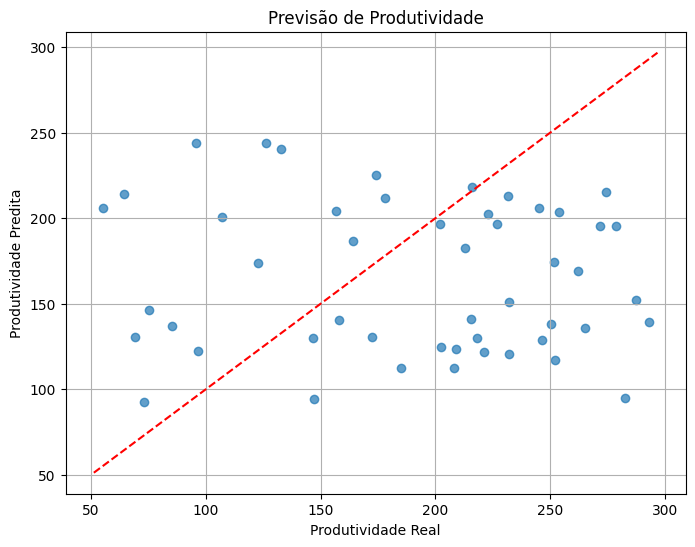

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# 1. Carregar o patches_enriched
data = pd.read_csv('patches_normalized_minmax.csv')

# 2. Selecionar variáveis
features = ['mean_ndvi', 'year']  # <- podemos incluir mais depois

# Adicionar uma coluna de produtividade simulada (exemplo)
np.random.seed(42)
data['produtividade'] = np.random.uniform(50, 300, size=len(data))  # valores entre 50 e 300 (exemplo)
target = 'produtividade'

X = data[features]
y = data[target]

# 3. Separar em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Criar e treinar o modelo
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. Fazer predições
y_pred = model.predict(X_test)

# 6. Avaliar o modelo
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"R²: {r2:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

# 7. Visualizar resultados
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel('Produtividade Real')
plt.ylabel('Produtividade Predita')
plt.title('Previsão de Produtividade')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # linha 45°
plt.grid(True)
plt.show()


## 🔍 Principais Insights

- O **NDVI** é um forte preditor da produtividade da cana.
- Houve variações sazonais claras que impactam a produtividade.
- Os anos de **2021 e 2023** mostraram padrões climáticos distintos, com variações abruptas de NDVI.
- A modelagem pode auxiliar na **tomada de decisão agrícola**, como o melhor período para adubação ou colheita.


